In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
dataset_dir = "/content/drive/MyDrive/Flying object detection/Augmented"

In [4]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True,
    seed=42
)

Found 9757 images belonging to 4 classes.
Found 2438 images belonging to 4 classes.


In [6]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(train_generator.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 6936s 23s/step - accuracy: 0.5384 - loss: 1.0452 - val_accuracy: 0.6440 - val_loss: 0.8778
Epoch 2/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 206s 675ms/step - accuracy: 0.7664 - loss: 0.5946 - val_accuracy: 0.6924 - val_loss: 0.9005
Epoch 3/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 199s 652ms/step - accuracy: 0.8405 - loss: 0.4084 - val_accuracy: 0.7256 - val_loss: 0.7495
Epoch 4/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 195s 638ms/step - accuracy: 0.8824 - loss: 0.3076 - val_accuracy: 0.7514 - val_loss: 0.7911
Epoch 5/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 189s 619ms/step - accuracy: 0.9212 - loss: 0.2105 - val_accuracy: 0.7231 - val_loss: 1.2758
Epoch 6/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 189s 619ms/step - accuracy: 0.9465 - loss: 0.1480 - val_accuracy: 0.7629 - val_loss: 0.9735
Epoch 7/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 193s 632ms/step - accuracy: 0.9637 - loss: 0.1090 - val_accuracy: 0.7535 - val_loss: 1.0520
Epoch 8/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 188s 617ms/step - accuracy: 0.9675 - 

In [9]:
loss, acc = model.evaluate(val_generator)
print(f"Валідаційна точність: {acc:.2f}")


77/77 ━━━━━━━━━━━━━━━━━━━━ 31s 397ms/step - accuracy: 0.7751 - loss: 1.1589
Валідаційна точність: 0.77


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


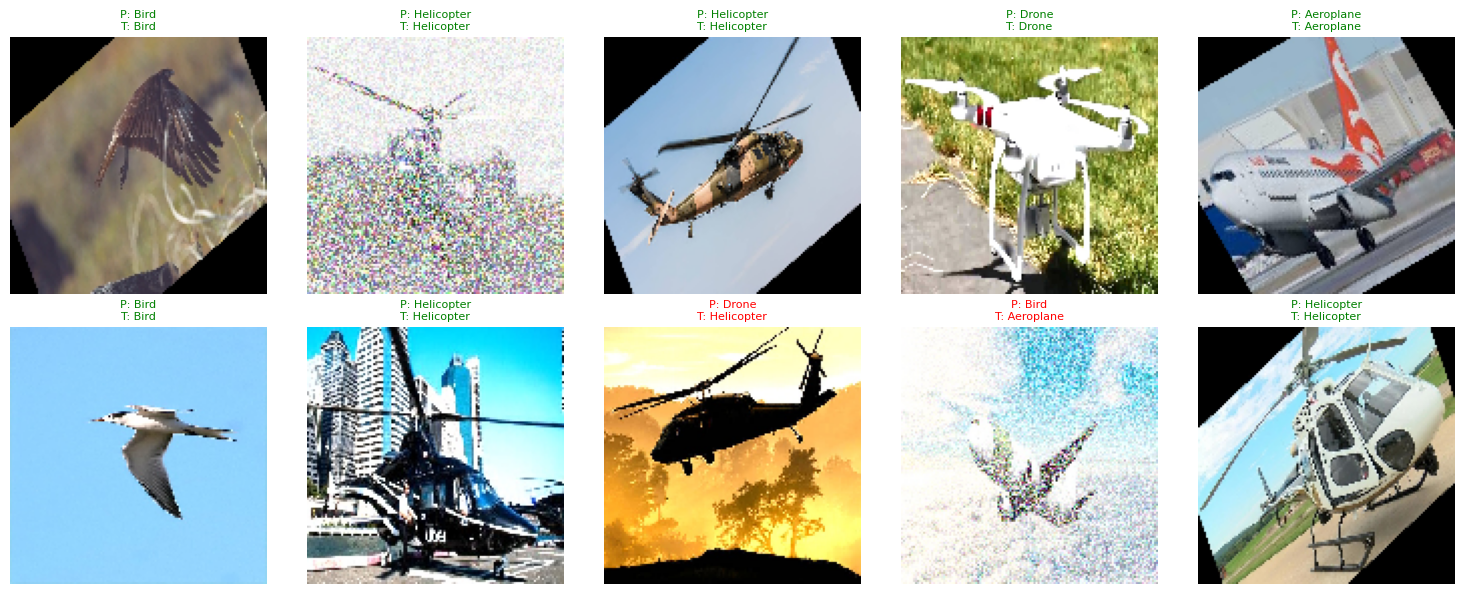

In [10]:
def plot_predictions(generator, model, n=10):
    class_labels = list(generator.class_indices.keys())
    x_batch, y_batch = next(generator)
    predictions = model.predict(x_batch[:n])
    pred_labels = np.argmax(predictions, axis=1)
    true_labels = np.argmax(y_batch[:n], axis=1)

    plt.figure(figsize=(15, 6))
    for i in range(n):
        plt.subplot(2, 5, i+1)
        plt.imshow(x_batch[i])
        pred = class_labels[pred_labels[i]]
        true = class_labels[true_labels[i]]
        color = 'green' if pred == true else 'red'
        plt.title(f"P: {pred}\nT: {true}", color=color, fontsize=8)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_predictions(val_generator, model)